# Preprocessing & On-the-fly Augmentation

This notebook builds the **complete data pipeline** for our pneumonia classification project. It is shared across all model notebooks (EfficientNet, SVM, etc.) via `%run` to ensure consistent preprocessing.

**Pipeline overview:**
1. Load the chest X-ray dataset from Hugging Face (`PAR8/chest-xray-pneumonia`),
2. Define **medically safe** augmentation transforms using Albumentations,
3. Apply transforms on-the-fly (augmentation is regenerated at each epoch),
4. Wrap everything into PyTorch `DataLoader` objects ready for training.

**Augmentation toggle:**
Augmentation can be turned off by setting `USE_AUGMENTATION = False` **before** running this notebook (useful for classical algorithms like SVM that may not benefit from on-the-fly augmentation). If the variable is not defined, augmentation is enabled by default.

**Three-class problem:**
| Label | Class | Description |
|-------|-------|-------------|
| 0 | NORMAL | Healthy lung |
| 1 | BACTERIA | Bacterial pneumonia |
| 2 | VIRUS | Viral pneumonia |

## 1. Install & Import

We use the following libraries:
- **Albumentations**: augmentation library designed for computer vision, supports medical-safe transforms and integrates with PyTorch via `ToTensorV2`,
- **datasets** (Hugging Face): to download and stream the chest X-ray dataset,
- **OpenCV** (`cv2`): used internally by Albumentations for image operations,
- **python-dotenv**: to securely load the Hugging Face API token from a `.env` file.

In [2]:
# Install if needed
# !pip install albumentations datasets torch pillow matplotlib numpy python-dotenv

import os
from dotenv import load_dotenv
load_dotenv()  # charge les variables depuis .env (ex: HF_TOKEN)

import albumentations as A
from albumentations.pytorch import ToTensorV2
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import random

print("Libraries imported successfully!")

c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## 2. Define medical-safe augmentation pipeline

Not all augmentation techniques are appropriate for medical imaging. For instance, **vertical flips** would produce anatomically impossible images (upside-down lungs), and aggressive **color jittering** could mask pathological features.

We follow the guidelines from [this survey on medical image augmentation](https://www.sciencedirect.com/science/article/pii/S277244252400042X#tbl7) and only apply transforms that preserve diagnostic information:

| Category | Transforms | Why safe |
|----------|-----------|----------|
| **Geometric** | Rotation (max 10°), shift/scale (max 10%), horizontal flip | Lungs are roughly symmetric; small geometric changes mimic patient positioning variability |
| **Elastic** | Elastic deformation, grid/optical distortion | Simulates soft-tissue deformation without altering lung structure |
| **Intensity** | Brightness/contrast, gamma, CLAHE | Mimics differences in X-ray exposure and scanner settings |
| **Blur/Sharpen** | Gaussian, median, motion blur, sharpening | Simulates focus/motion artifacts from real scanners |
| **Noise** | Gaussian, ISO, multiplicative noise | Mimics sensor noise inherent to X-ray acquisition |

Two pipelines are created:
- **`train_transform`**: full augmentation + ImageNet normalization (applied on-the-fly, different each epoch),
- **`val_test_transform`**: only resize + normalization (no augmentation, deterministic).

In [3]:
train_transform = A.Compose([
    # Resize to fixed size
    A.Resize(224, 224),

    # Geometric transformations
    A.Rotate(
        limit=10,  # Max 10°
        border_mode=cv2.BORDER_CONSTANT,
        p=0.7
    ),

    A.ShiftScaleRotate(
        shift_limit=0.1,       # +10% translation
        scale_limit=0.1,       # 90-110% zoom
        rotate_limit=0,
        p=0.7,
        border_mode=cv2.BORDER_CONSTANT,
    ),

    # Horizontal flip only (lungs are symmetric)
    A.HorizontalFlip(p=0.5),

    # Elastic deformation
    A.ElasticTransform(
        alpha=1,
        sigma=50,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.2
    ),

    # Perspective & distortion
    A.OneOf([
        A.GridDistortion(
            num_steps=5,
            distort_limit=0.2,
            border_mode=cv2.BORDER_CONSTANT,
            p=1.0
        ),
        A.OpticalDistortion(
            distort_limit=0.3,
            border_mode=cv2.BORDER_CONSTANT,
            p=1.0
        ),
    ], p=0.3),

    # Intensity modifications
    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=1.0
        ),
        A.RandomGamma(gamma_limit=(80, 120), p=1.0),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
    ], p=0.9),

    # Blur & sharpening
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0),
    ], p=0.4),

    # Noise
    A.OneOf([
        A.GaussNoise(p=1.0),
        A.ISONoise(
            color_shift=(0.01, 0.03),
            intensity=(0.05, 0.3),
            p=1.0
        ),
        A.MultiplicativeNoise(
            multiplier=(0.95, 1.05),
            per_channel=True,
            p=1.0
        ),
    ], p=0.3),

    # Normalize & convert to tensor
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
# Validation/Test
val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("\nAugmentation pipelines created!\n")


Augmentation pipelines created!



c:\Users\sh4rk\AppData\Local\Programs\Python\Python312\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 3. Load dataset

The dataset is hosted on Hugging Face as [`PAR8/chest-xray-pneumonia`](https://huggingface.co/datasets/PAR8/chest-xray-pneumonia). It contains **5 851** chest X-ray images split into three sets:

- **Train** (80%): used to learn model weights, with augmentation applied on-the-fly,
- **Validation** (9%): used to monitor performance during training and tune hyperparameters,
- **Test** (11%): held out for final evaluation, never seen during training.

Access requires a Hugging Face token stored in a `.env` file (`KEY_HUGGING_FACE`).

In [4]:
# Load dataset from HuggingFace (token lu depuis .env : HF_TOKEN)
print("Loading dataset...")
hf_token = os.getenv("KEY_HUGGING_FACE")
dataset = load_dataset("PAR8/chest-xray-pneumonia", token=hf_token)

print(f"\n  Dataset loaded!")
print(f"  Train: {len(dataset['train'])} images")
print(f"  Validation: {len(dataset['validation'])} images")
print(f"  Test: {len(dataset['test'])} images")


Loading dataset...

  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images


### Class distribution per split

Understanding the class balance is critical: an imbalanced dataset can bias the model toward the majority class. The chart below shows how many images belong to each class (normal, bacteria, virus) across the train, validation, and test splits.

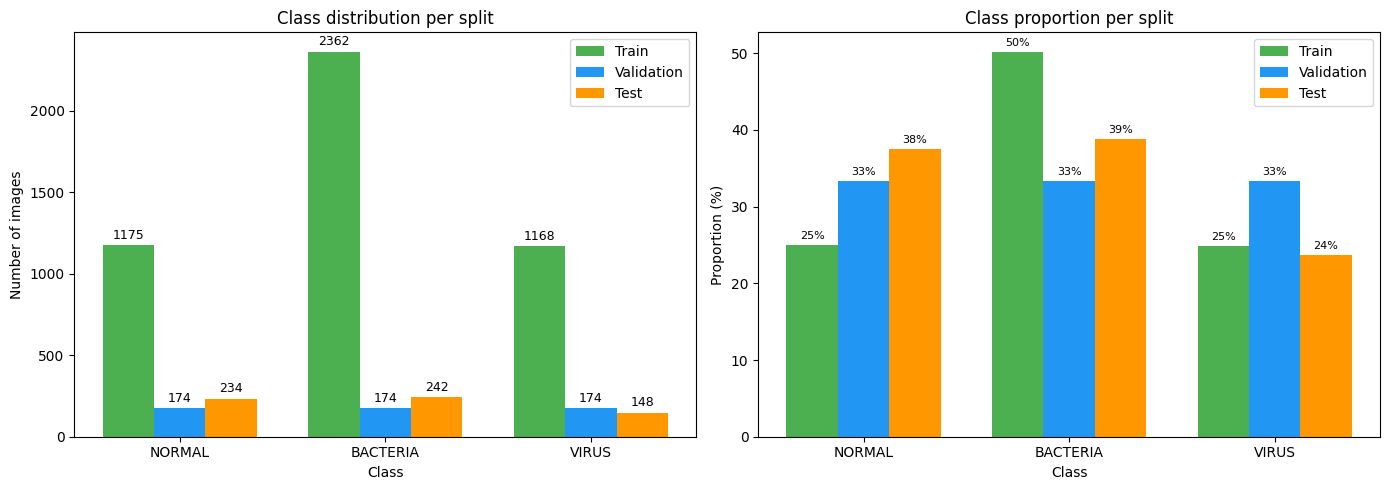


Summary:
Split          NORMAL   BACTERIA    VIRUS    Total
--------------------------------------------------
Train            1175       2362     1168     4705
Validation        174        174      174      522
Test              234        242      148      624


In [5]:
import collections

label_names = {0: "NORMAL", 1: "BACTERIA", 2: "VIRUS"}
splits = {"Train": dataset["train"], "Validation": dataset["validation"], "Test": dataset["test"]}

# Count classes per split
split_counts = {}
for split_name, split_data in splits.items():
    counter = collections.Counter(split_data["label"])
    split_counts[split_name] = [counter.get(i, 0) for i in range(3)]

# --- Grouped bar chart ---
class_labels = [label_names[i] for i in range(3)]
split_names = list(split_counts.keys())
x = np.arange(len(class_labels))
width = 0.25
colors = ["#4caf50", "#2196f3", "#ff9800"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar chart
for i, (split_name, color) in enumerate(zip(split_names, colors)):
    counts = split_counts[split_name]
    bars = axes[0].bar(x + i * width, counts, width, label=split_name, color=color)
    for bar, count in zip(bars, counts):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                     str(count), ha="center", va="bottom", fontsize=9)

axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Class distribution per split")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(class_labels)
axes[0].legend()

# Right: stacked bar chart (proportions)
for i, (split_name, color) in enumerate(zip(split_names, colors)):
    counts = split_counts[split_name]
    total = sum(counts)
    proportions = [c / total * 100 for c in counts]
    bars = axes[1].bar(x + i * width, proportions, width, label=split_name, color=color)
    for bar, pct in zip(bars, proportions):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f"{pct:.0f}%", ha="center", va="bottom", fontsize=8)

axes[1].set_xlabel("Class")
axes[1].set_ylabel("Proportion (%)")
axes[1].set_title("Class proportion per split")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(class_labels)
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary table
print("\nSummary:")
print(f"{'Split':<12} {'NORMAL':>8} {'BACTERIA':>10} {'VIRUS':>8} {'Total':>8}")
print("-" * 50)
for split_name in split_names:
    counts = split_counts[split_name]
    print(f"{split_name:<12} {counts[0]:>8} {counts[1]:>10} {counts[2]:>8} {sum(counts):>8}")

## 4. Apply transforms to dataset

We use Hugging Face's `with_transform()` method to apply our augmentation pipelines **on-the-fly**. This means:

- Transforms are applied lazily each time an image is accessed, not stored in memory,
- **Training images get a different augmentation every time** they are loaded (different each epoch), effectively multiplying dataset diversity without increasing storage,
- **Validation/test images** only get resized and normalized (no augmentation) to ensure reproducible evaluation.

Each image is converted from PIL to a NumPy array (RGB), transformed by Albumentations, and returned as a PyTorch tensor.

In [ ]:
# Toggle augmentation on/off.
# Set USE_AUGMENTATION = False BEFORE `%run`-ing this notebook to disable augmentation
# (e.g. for classical algorithms like SVM). Defaults to True.
try:
    USE_AUGMENTATION
except NameError:
    USE_AUGMENTATION = True

active_train_transform = train_transform if USE_AUGMENTATION else val_test_transform

# Transform functions

# Apply (augmented or plain) transforms to training images
def apply_train_transforms(examples):
    images = []
    for img in examples['image']:
        img_array = np.array(img.convert('RGB'))
        transformed = active_train_transform(image=img_array)
        images.append(transformed['image'])

    return {'image': images, 'label': examples['label']}

# Apply only normalization
def apply_val_test_transforms(examples):
    images = []
    for img in examples['image']:
        img_array = np.array(img.convert('RGB'))
        transformed = val_test_transform(image=img_array)
        images.append(transformed['image'])

    return {'image': images, 'label': examples['label']}

# Apply to datasets
train_data = dataset['train'].with_transform(apply_train_transforms)
val_data = dataset['validation'].with_transform(apply_val_test_transforms)
test_data = dataset['test'].with_transform(apply_val_test_transforms)

print(f"\n Transforms applied! (augmentation = {'ON' if USE_AUGMENTATION else 'OFF'})")
if USE_AUGMENTATION:
    print(" Training images will be augmented on-the-fly when you load them")
else:
    print(" Training images will only be resized + normalized (no augmentation)")

## 5. Visualize augmentation

To verify that our augmentation pipeline produces realistic-looking X-rays, we display one random training image alongside 8 augmented versions. Each call to `train_data[idx]` applies a new random augmentation, so every version looks slightly different.

If `USE_AUGMENTATION = False`, this section is skipped because all 8 panels would be identical (only resize + normalization are applied).

This visual check helps confirm that:
- the transformations preserve diagnostic features (opacities, lung contours),
- no augmentation produces unrealistic artifacts.

In [ ]:
# Denormalize for visualization
def denormalize(tensor):
    import torch
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

if not USE_AUGMENTATION:
    print("Augmentation is OFF — skipping augmentation preview.")
else:
    # Get original image
    sample_idx = random.randint(1, 10)
    original_img = dataset['train'][sample_idx]['image']
    label = dataset['train'][sample_idx]['label']
    label_names = {0: "NORMAL", 1: "BACTERIA", 2: "VIRUS"}

    # Create visualization
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    # Original
    axes[0].imshow(original_img)
    axes[0].set_title('ORIGINAL', fontsize=14, fontweight='bold', color='green')
    axes[0].axis('off')

    # 8 augmented versions
    for i in range(8):
        aug_img = train_data[sample_idx]['image']
        aug_img_display = denormalize(aug_img).permute(1, 2, 0).numpy()
        aug_img_display = np.clip(aug_img_display, 0, 1)

        axes[i+1].imshow(aug_img_display)
        axes[i+1].set_title(f'#{i+1}', fontsize=15)
        axes[i+1].axis('off')

    plt.suptitle(f'IMG NUMBER {sample_idx} ({label_names[label]})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Create DataLoaders

PyTorch `DataLoader` wraps our datasets into iterable batches for training. Key settings:

- **`batch_size=32`**: each training step processes 32 images at once (good balance between memory usage and gradient stability),
- **`shuffle=True`** (train only): randomizes the order of samples each epoch to prevent the model from memorizing sequence patterns,
- **`num_workers=0`**: data loading runs in the main process (avoids multiprocessing issues on Windows),
- **`pin_memory=True`** (when GPU available): speeds up CPU-to-GPU data transfer.

The resulting DataLoaders (`train_loader`, `val_loader`, `test_loader`) are used by all downstream model notebooks.

In [8]:
import torch
from torch.utils.data import DataLoader

# Configuration
BATCH_SIZE = 32
NUM_WORKERS = 0

# Create DataLoaders
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\n  DataLoaders ready!")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20


## 7. Sanity check - Load a batch

As a final verification, we load one batch from `train_loader` and display all 32 images. This confirms that:
- tensor shapes are correct (`[32, 3, 224, 224]`),
- labels are properly assigned,
- augmented images look reasonable when denormalized back to pixel space.

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 0, 1, 1, 1, 0, 1, 0, 1, 1]
Label distribution: [10, 15, 7]


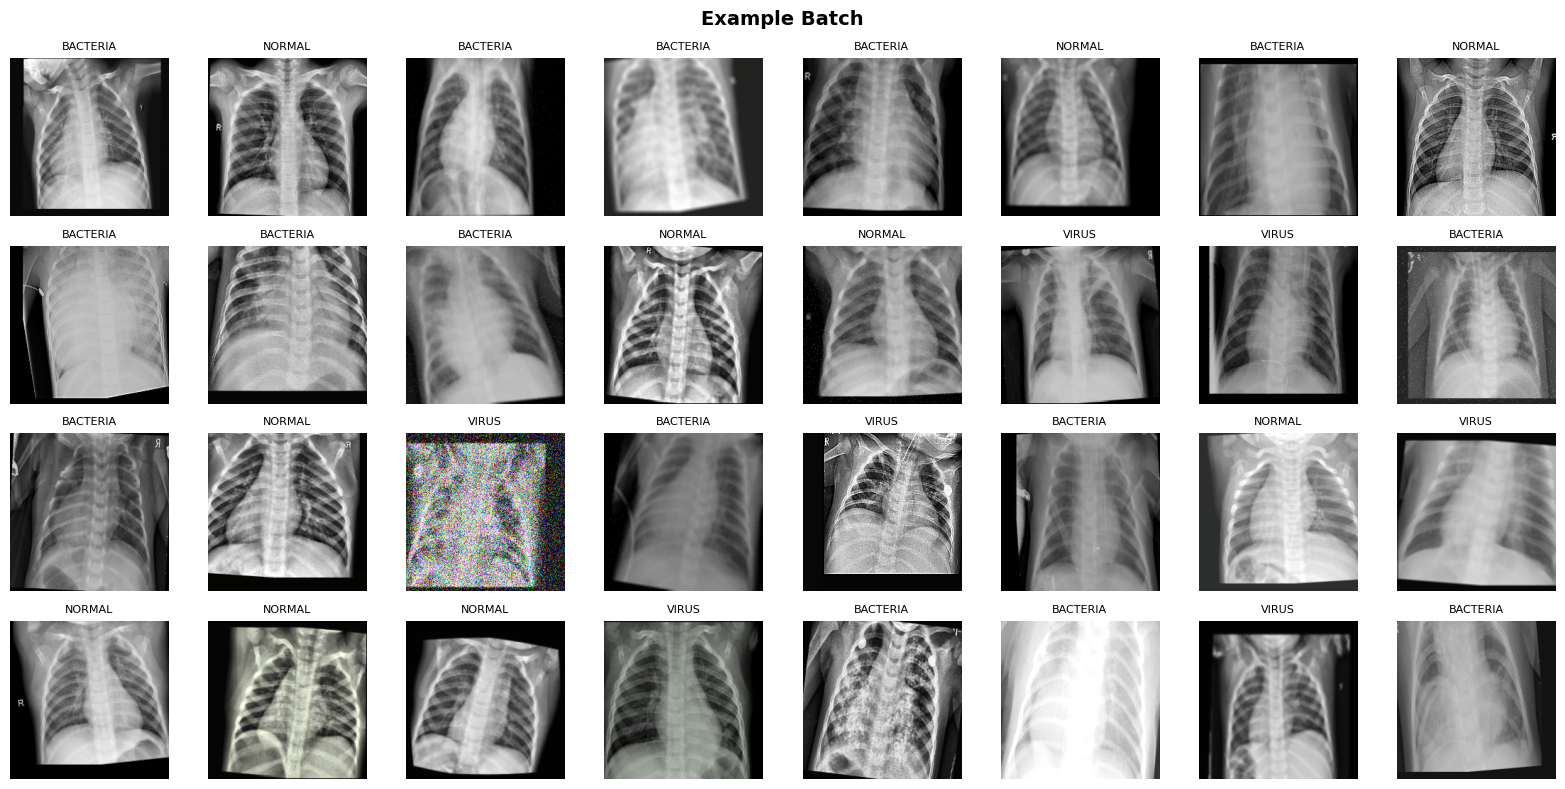

In [9]:
# Get one batch
batch = next(iter(train_loader))
images = batch['image']  # Augmented images as tensors
labels = batch['label']  # Labels

print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nFirst 10 labels: {labels[:10].tolist()}")
print(f"Label distribution: {torch.bincount(labels).tolist()}")

# Visualize batch
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(32, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(f'{label_names[labels[i].item()]}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Example Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()